# 01 — Análise Exploratória de Dados (EDA)
**Classificação de gênero musical — GTZAN / CNN sobre espectrogramas Mel**

Este notebook explora o dataset GTZAN antes da modelagem, cobrindo o entregável
*Dados e preparação* do projeto: distribuição das classes, propriedades do áudio,
visualização de formas de onda e espectrogramas Mel, inspeção das imagens prontas,
features tabulares, estratégia de divisão treino/validação/teste e discussão de
vieses e limitações.

Todos os parâmetros vêm de `src/config.py` (fonte única da verdade).

In [1]:
import sys, os
from pathlib import Path

# Permite importar o pacote src/ a partir de notebooks/
REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import librosa, librosa.display

from src import config as C
from src import audio, data

%matplotlib inline
plt.rcParams["figure.dpi"] = 100
np.random.seed(C.SEED)
print("Dataset:", C.GTZAN_DIR)
print("Gêneros:", C.GENRES)
print(f"Parâmetros Mel: sr={C.SAMPLE_RATE}, n_mels={C.N_MELS}, n_fft={C.N_FFT}, hop={C.HOP_LENGTH}")
print(f"Segmentação: {C.SEGMENT_DURATION}s -> {C.SEGMENTS_PER_TRACK} segmentos/música")

Dataset: C:\Users\User\Downloads\archive\gtzan-dataset
Gêneros: ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']
Parâmetros Mel: sr=22050, n_mels=128, n_fft=2048, hop=512
Segmentação: 3.0s -> 10 segmentos/música


## 1. Inventário do dataset e distribuição das classes

Construímos um índice no nível de *música* (uma linha por clipe de 30s). O arquivo
corrompido `jazz.00054.wav` (cujo PNG também está ausente) é excluído.

In [2]:
index = data.build_track_index()
print(f"Total de músicas (após excluir corrompidos): {len(index)}")
print(f"Músicas com PNG correspondente: {index['has_image'].sum()}")
counts = index["genre"].value_counts().reindex(C.GENRES)
display(counts.to_frame("n_músicas"))

Total de músicas (após excluir corrompidos): 999
Músicas com PNG correspondente: 999


,n_músicas
genre,
blues,100
classical,100
country,100
disco,100
hiphop,100
jazz,99
metal,100
pop,100
reggae,100


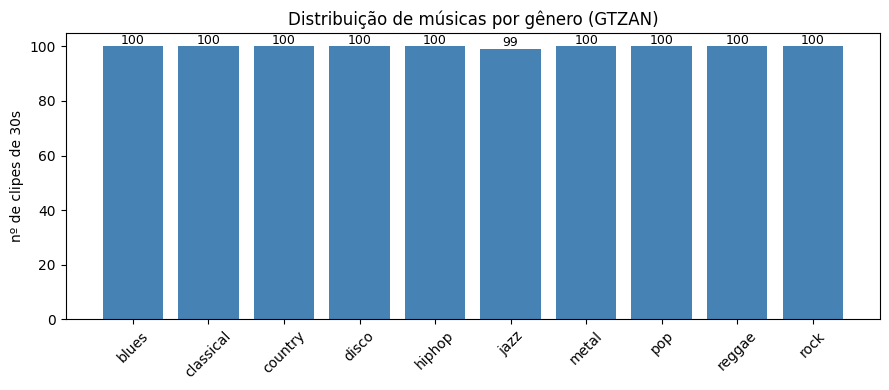

In [3]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(counts.index, counts.values, color="steelblue")
ax.set_title("Distribuição de músicas por gênero (GTZAN)")
ax.set_ylabel("nº de clipes de 30s"); ax.set_ylim(0, 105)
for i, v in enumerate(counts.values):
    ax.text(i, v + 1, str(v), ha="center", fontsize=9)
plt.xticks(rotation=45); plt.tight_layout(); plt.show()

O dataset é **quase perfeitamente balanceado**: 100 clipes por gênero, exceto
*jazz* com 99 após removermos o arquivo corrompido. Isso dispensa técnicas de
balanceamento; *accuracy* é uma métrica adequada, mas reportaremos também o
**F1-score macro** para tratar todas as classes igualmente.

## 2. Propriedades do áudio

Conferimos taxa de amostragem, duração e nº de canais em uma amostra de clipes.

In [4]:
sample = index.sample(6, random_state=C.SEED)
rows = []
for _, r in sample.iterrows():
    y = audio.load_audio(r["path"])
    rows.append({"arquivo": r["filename"], "gênero": r["genre"],
                 "sr": C.SAMPLE_RATE, "duração_s": round(len(y)/C.SAMPLE_RATE, 2),
                 "nº_amostras": len(y)})
display(pd.DataFrame(rows))

,arquivo,gênero,sr,duração_s,nº_amostras
0,hiphop.00053.wav,hiphop,22050,30.01,661794
1,pop.00094.wav,pop,22050,30.00,661504
2,country.00009.wav,country,22050,30.08,663300
3,disco.00009.wav,disco,22050,30.01,661794
4,pop.00041.wav,pop,22050,30.00,661504
5,jazz.00079.wav,jazz,22050,30.01,661794


## 3. Formas de onda — uma amostra por gênero

A forma de onda mostra a envoltória de energia ao longo do tempo. Já dá para notar
diferenças: *metal* tende a ser denso e saturado; *classical* mais dinâmico e esparso.

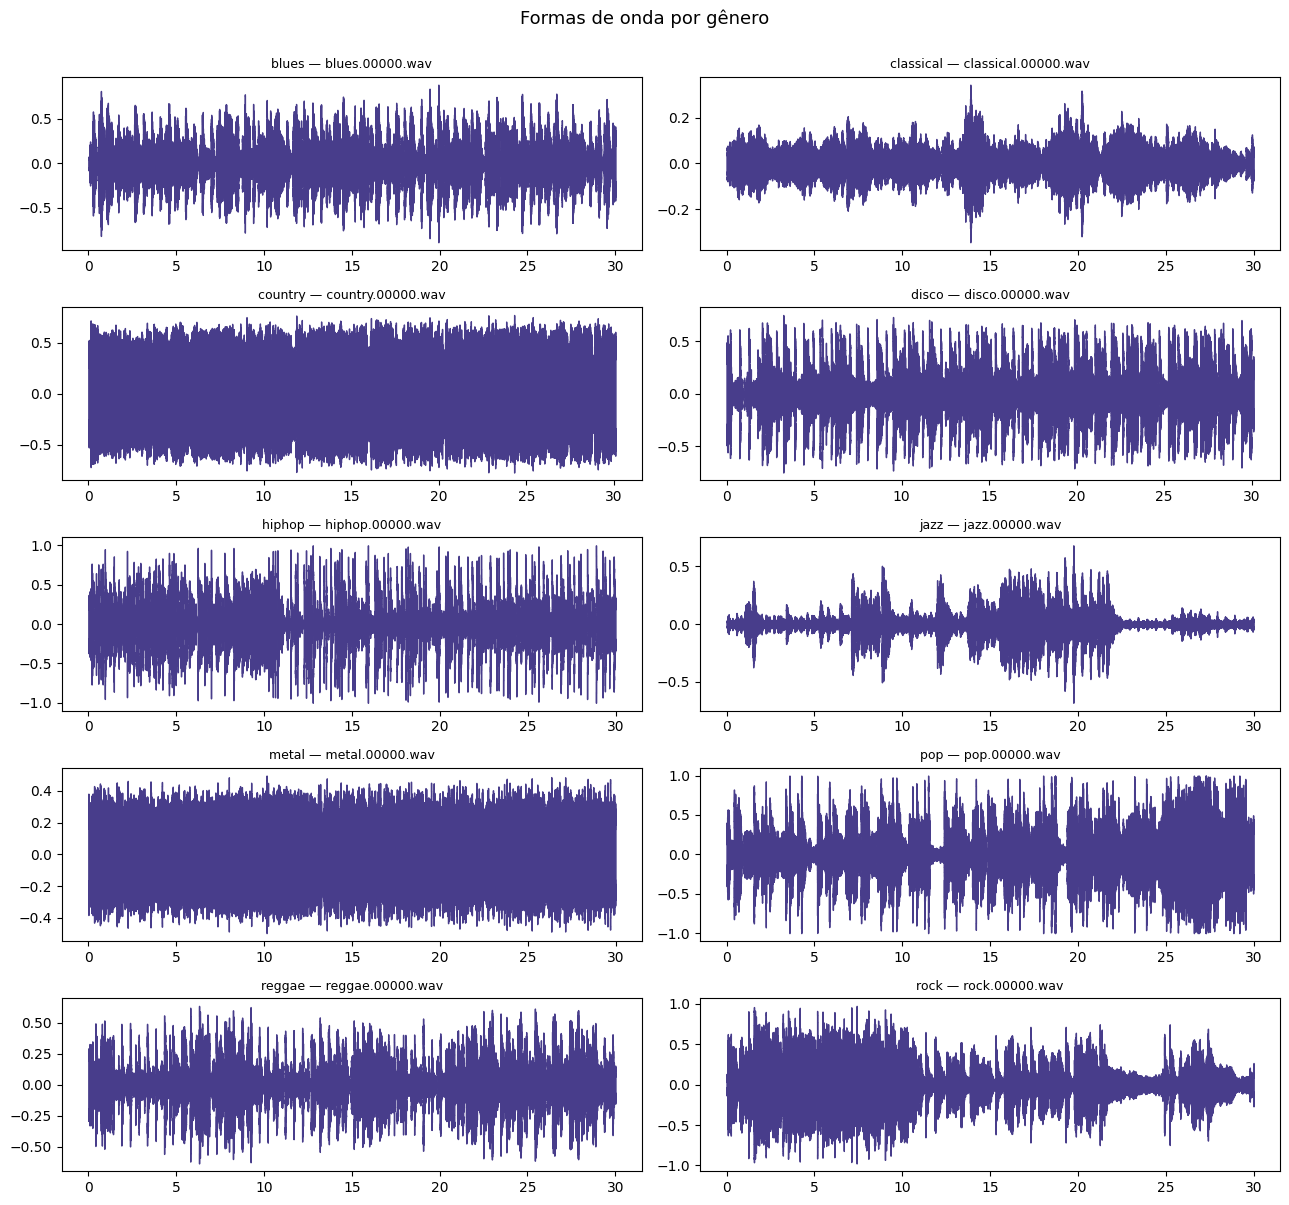

In [5]:
fig, axes = plt.subplots(5, 2, figsize=(13, 12))
for ax, genre in zip(axes.ravel(), C.GENRES):
    row = index[index.genre == genre].iloc[0]
    y = audio.load_audio(row["path"])
    librosa.display.waveshow(y, sr=C.SAMPLE_RATE, ax=ax, color="darkslateblue")
    ax.set_title(f"{genre} — {row['filename']}", fontsize=9)
    ax.set_xlabel(""); ax.set_ylabel("")
plt.suptitle("Formas de onda por gênero", y=1.0, fontsize=13)
plt.tight_layout(); plt.show()

## 4. Espectrogramas Mel — uma amostra por gênero

O espectrograma Mel (em dB) é a **entrada da CNN**: eixo Y = bandas Mel (frequência
percebida), eixo X = tempo, cor = energia. É aqui que padrões visuais distinguem os
gêneros — exatamente o que a rede convolucional vai aprender.

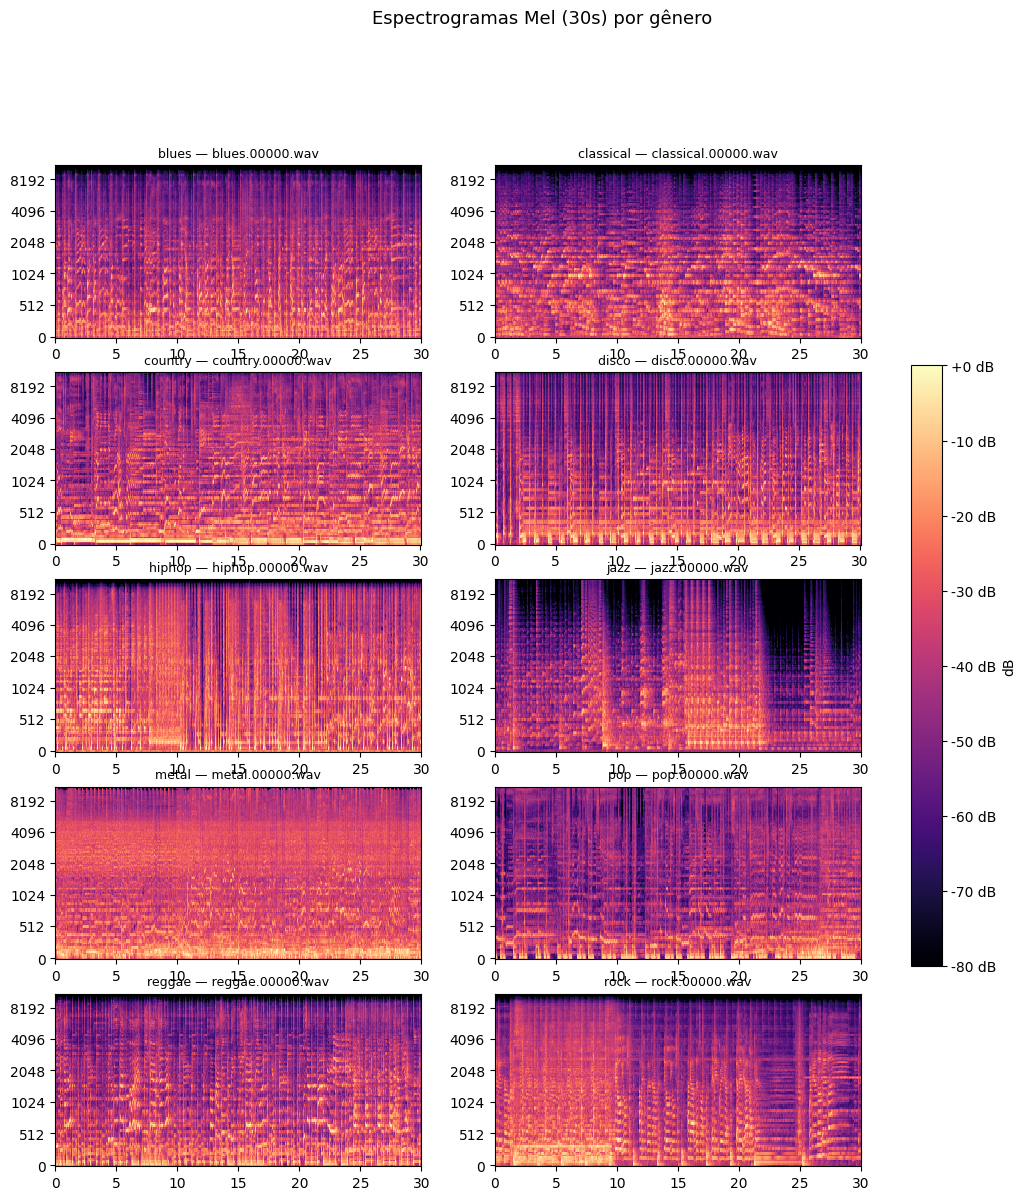

In [6]:
fig, axes = plt.subplots(5, 2, figsize=(13, 13))
for ax, genre in zip(axes.ravel(), C.GENRES):
    row = index[index.genre == genre].iloc[0]
    y = audio.load_audio(row["path"])
    S_db = audio.mel_spectrogram_db(y)
    img = librosa.display.specshow(S_db, sr=C.SAMPLE_RATE, hop_length=C.HOP_LENGTH,
                                   x_axis="time", y_axis="mel", ax=ax, cmap="magma")
    ax.set_title(f"{genre} — {row['filename']}", fontsize=9)
    ax.set_xlabel(""); ax.set_ylabel("")
fig.colorbar(img, ax=axes.ravel().tolist(), format="%+2.0f dB", shrink=0.6, label="dB")
plt.suptitle("Espectrogramas Mel (30s) por gênero", y=1.0, fontsize=13)
plt.show()

## 5. Segmentação em 3 segundos

Cada clipe de 30s é dividido em **10 segmentos de 3s**, multiplicando ~10× o número
de amostras (de ~1000 para ~10000) — crucial para treinar uma CNN com dados
limitados. Abaixo, os 10 segmentos de um clipe e a forma final do espectrograma que
alimentará a rede.

rock.00000.wav: 10 segmentos de 3.0s
Shape do espectrograma de um segmento (entrada da CNN): (128, 130)  -> (n_mels, frames)


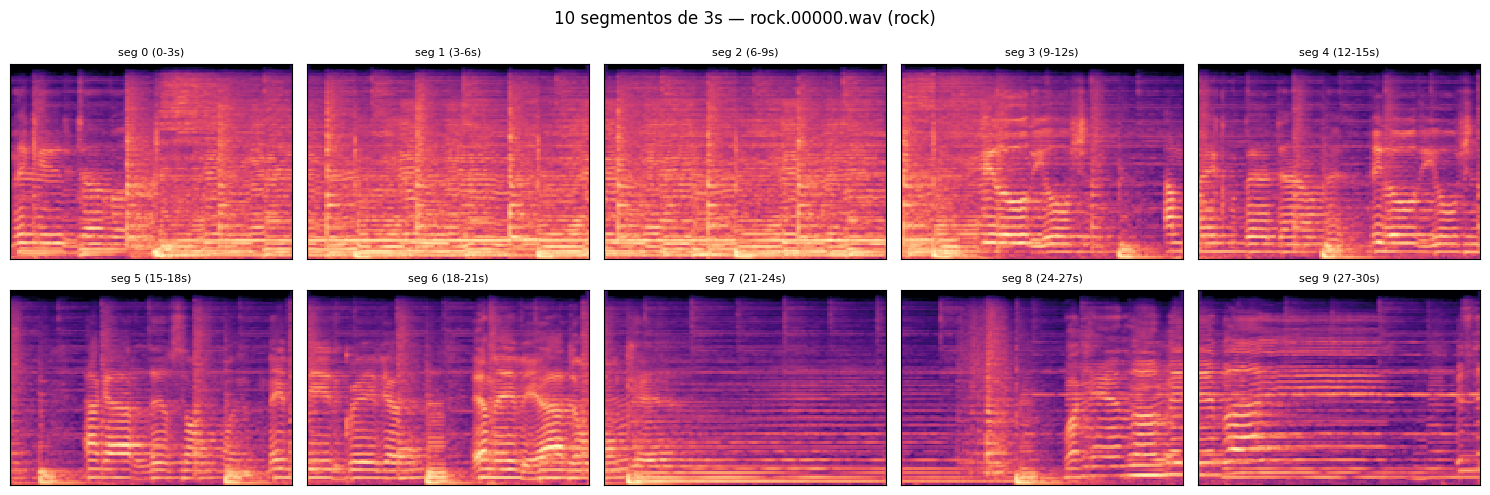

In [7]:
row = index[index.genre == "rock"].iloc[0]
y = audio.load_audio(row["path"])
segments = audio.segment_waveform(y)
print(f"{row['filename']}: {len(segments)} segmentos de {C.SEGMENT_DURATION}s")

seg_spec = audio.mel_spectrogram_db(segments[0])
print(f"Shape do espectrograma de um segmento (entrada da CNN): {seg_spec.shape}  -> (n_mels, frames)")

fig, axes = plt.subplots(2, 5, figsize=(15, 5))
for ax, (i, seg) in zip(axes.ravel(), enumerate(segments)):
    S_db = audio.mel_spectrogram_db(seg)
    librosa.display.specshow(S_db, sr=C.SAMPLE_RATE, hop_length=C.HOP_LENGTH,
                             ax=ax, cmap="magma")
    ax.set_title(f"seg {i} ({i*3}-{i*3+3}s)", fontsize=8)
    ax.set_xticks([]); ax.set_yticks([])
plt.suptitle(f"10 segmentos de 3s — {row['filename']} (rock)", fontsize=12)
plt.tight_layout(); plt.show()

## 6. Imagens prontas (`images_original`)

O GTZAN também traz espectrogramas como PNG. Vamos usá-los como **segunda fonte de
entrada** para comparação. Note que possuem eixos/margens (ruído visual) e são do
clipe inteiro de 30s.

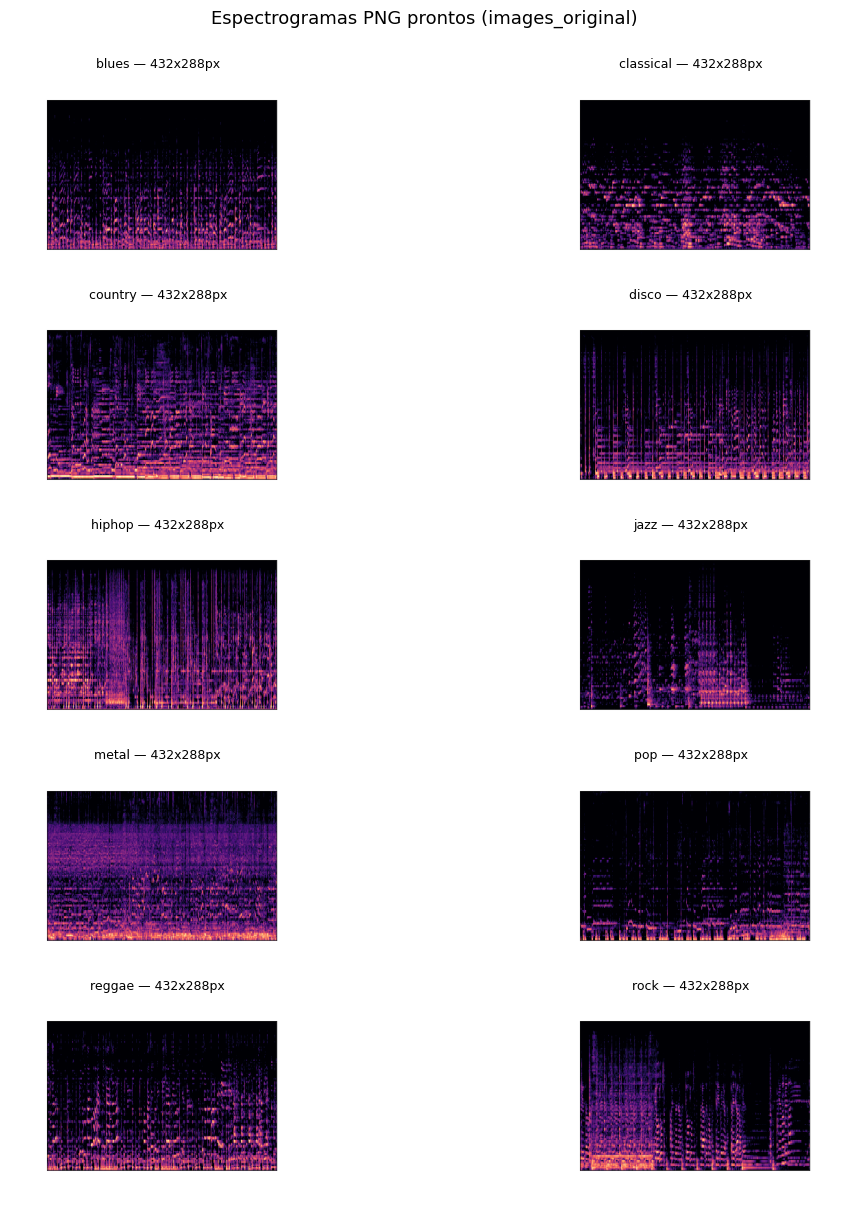

Dimensão das PNGs: (432, 288)


In [8]:
from PIL import Image
img_rows = index[index.has_image].groupby("genre").first().reset_index()
fig, axes = plt.subplots(5, 2, figsize=(13, 12))
for ax, (_, r) in zip(axes.ravel(), img_rows.iterrows()):
    im = Image.open(r["image_path"])
    ax.imshow(im); ax.set_title(f"{r['genre']} — {im.size[0]}x{im.size[1]}px", fontsize=9)
    ax.axis("off")
plt.suptitle("Espectrogramas PNG prontos (images_original)", y=1.0, fontsize=13)
plt.tight_layout(); plt.show()
print("Dimensão das PNGs:", Image.open(img_rows.iloc[0]['image_path']).size)

## 7. Features tabulares — separabilidade dos gêneros

`features_30_sec.csv` traz features de áudio já extraídas (MFCCs, centróide
espectral, etc.). Não as usaremos na CNN, mas uma projeção PCA 2D ajuda a visualizar
o quão separáveis são os gêneros — e a antecipar quais tendem a se confundir.

Shape: (1000, 60)


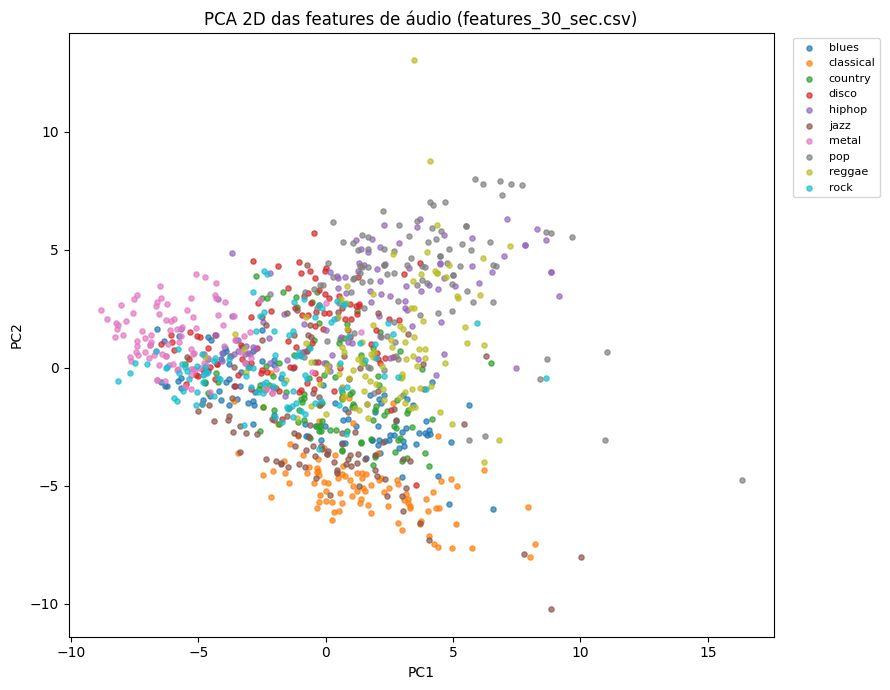

In [9]:
feats = pd.read_csv(C.FEATURES_30S_CSV)
print("Shape:", feats.shape)
X = feats.drop(columns=["filename", "length", "label"])
y_lab = feats["label"]

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
Xs = StandardScaler().fit_transform(X)
pcs = PCA(n_components=2, random_state=C.SEED).fit_transform(Xs)

fig, ax = plt.subplots(figsize=(9, 7))
for genre in C.GENRES:
    m = (y_lab == genre).values
    ax.scatter(pcs[m, 0], pcs[m, 1], s=14, alpha=0.7, label=genre)
ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
ax.set_title("PCA 2D das features de áudio (features_30_sec.csv)")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout(); plt.show()

*classical* e *metal* costumam aparecer bem separados; *rock*, *country* e *disco*
tendem a se sobrepor — espere confusões nessas classes na matriz de confusão da CNN.

## 8. Divisão treino / validação / teste (por música)

**Ponto crítico de metodologia:** com segmentos de 3s, a divisão é feita por *música*,
não por segmento. Assim, nenhum trecho de uma mesma música aparece em splits
diferentes (evita vazamento de dados). A divisão é estratificada por gênero.

In [10]:
split_idx = data.split_tracks(index)
tbl = split_idx.groupby(["genre", "split"]).size().unstack(fill_value=0)[["train", "val", "test"]]
display(tbl)
print("\nTotais por split (músicas):")
print(split_idx["split"].value_counts())
print(f"\nEstimativa de segmentos de 3s: treino≈{(split_idx.split=='train').sum()*C.SEGMENTS_PER_TRACK}, "
      f"val≈{(split_idx.split=='val').sum()*C.SEGMENTS_PER_TRACK}, "
      f"teste≈{(split_idx.split=='test').sum()*C.SEGMENTS_PER_TRACK}")

split,train,val,test
genre,,,
blues,70,15,15
classical,70,15,15
country,70,15,15
disco,70,15,15
hiphop,70,15,15
jazz,69,15,15
metal,70,15,15
pop,70,15,15
reggae,70,15,15



Totais por split (músicas):
split
train    699
val      150
test     150
Name: count, dtype: int64

Estimativa de segmentos de 3s: treino≈6990, val≈1500, teste≈1500


## 9. Vieses e limitações do dataset (para o relatório)

- **Arquivo corrompido:** `jazz.00054.wav` está corrompido e foi removido (jazz fica com 99 clipes).
- **Duplicatas e ruído de rótulo:** o GTZAN é conhecido por conter clipes duplicados/repetidos
  e alguns rótulos questionáveis (Sturm, 2013), o que infla o desempenho real.
- **Condições de gravação:** parte dos clipes compartilha fonte/qualidade de gravação, o que
  a rede pode usar como atalho em vez de aprender o gênero de fato.
- **Vazamento por segmento:** mitigado com a divisão **por música**.
- **Representatividade:** apenas 10 gêneros ocidentais, 30s por faixa, coletado por volta de 2002 —
  não generaliza para música atual nem para gêneros fora dessa lista.
- **Escopo de uso:** classificador acadêmico/educacional; não deve ser usado para decisões
  comerciais ou de curadoria sem validação adicional.

**Próximo passo:** `02_preprocessing.ipynb` — gerar e cachear os espectrogramas Mel de 3s
(fonte librosa) e preparar os PNGs (fonte imagem) conforme a divisão definida aqui.